# TF-IDF + Logistic Regression baseline

This notebook trains our baseline intent classifier. Each message is turned into
TF-IDF word weights, and a logistic regression model predicts one of the 14 intents.
The more advanced models (XLM-RoBERTa, Jev API) will be compared against this baseline.
## 1. Imports

In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import joblib 

from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import sys
sys.path.insert(0, '..')


from sklearn.metrics import f1_score
from src.evaluate import evaluate
SEED = 42

## 2. Load the data

We use the train / validation / test split created in `01_preprocessing.ipynb`
(70 / 15 / 15, stratified by intent, seed 42).
- **train**: used to fit the model
- **validation**: used to choose the hyperparameter C
- **test**: used only once, at the end, for the final score


In [2]:
# Read the three splits
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df =  pd.read_csv("../data/processed/test.csv")


# Check the sizes and that the intents are balanced
print("train: ", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)
print()
print(train_df["intent"].value_counts())


# X = input messages, y = correct intents
X_train, y_train = train_df["text"], train_df["intent"]
X_val, y_val = val_df["text"], val_df["intent"]
X_test, y_test = test_df["text"], test_df["intent"]

train:  (2104, 2)
val:   (451, 2)
test:  (452, 2)

intent
latest_transactions    151
joint_account          151
abroad                 151
atm_limit              151
address                150
pay_bill               150
freeze                 150
cash_deposit           150
app_error              150
card_issues            150
business_loan          150
high_value_payment     150
direct_debit           150
balance                150
Name: count, dtype: int64


## 3. The model

The model is a scikit-learn **Pipeline** with two steps:

1. **TfidfVectorizer** turns each message into a vector of word weights.
   - `ngram_range=(1, 2)`: uses single words *and* word pairs (e.g. "lost card")
   - `sublinear_tf=True`: uses log(count), so a word repeated many times doesn't dominate
2. **LogisticRegression** learns which words point to which intent.
   - `C` controls regularization: small C = simpler model, large C = fits training data more closely

Using a Pipeline means TF-IDF learns its vocabulary only from the training data,
so no information leaks from the validation or test sets.


In [3]:
def build_pipeline(C):
    """Create a TF-IDF + logistic regression pipeline with the given C."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
        ("clf", LogisticRegression(C=C, max_iter=1000, random_state=SEED)),
    ])

## 4. Tune C on the validation set

We train one model per C value on the training set and score it on the validation set
with macro-F1. The C with the best validation score is used for the final model.
The test set is **not** used here.

In [4]:
C_values = [0.01, 0.1, 1, 10, 100, 1000, 10000]
results = []

for C in C_values:
    model = build_pipeline(C)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    score =  f1_score(y_val, val_preds, average="macro")
    results.append({"C": C, "val_macro_f1": round(score, 4)})

tuning_df = pd.DataFrame(results)
print(tuning_df)

best_C = tuning_df.loc[tuning_df["val_macro_f1"].idxmax(), "C"]
print("\nBest C:", best_C)


          C  val_macro_f1
0      0.01        0.9042
1      0.10        0.9123
2      1.00        0.9349
3     10.00        0.9571
4    100.00        0.9617
5   1000.00        0.9530
6  10000.00        0.9258

Best C: 100.0


Validation macro-F1 for each C (log scale, since C grows by powers of 10):


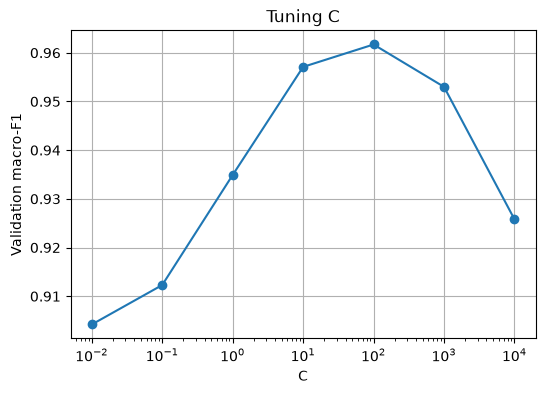

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(tuning_df["C"], tuning_df["val_macro_f1"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation macro-F1")
plt.title("Tuning C")
plt.grid(True)
plt.show()


## 5. Train the final model

We train a new model with the best C on the training set.


In [6]:
final_model = build_pipeline(best_C)
final_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](14,)","['abroad','address','app_error',...,'joint_account','latest_transactions', 'pay_bill']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


## 6. Evaluate on the test set

The test set is used only once, here. We use the shared `evaluate()` function
so the results are comparable with the other models. It prints the per-intent
report, saves the confusion matrix and adds a row to `results/metrics.csv`.


In [7]:
test_preds = final_model.predict(X_test)

metrics = evaluate(y_test, test_preds, "tfidf_lr", "synthetic_test", out_dir="../results")
metrics


=== tfidf_lr on synthetic_test ===
Accuracy: 0.9403   Macro-F1: 0.9386

                     precision    recall  f1-score   support

             abroad       0.88      0.69      0.77        32
            address       1.00      0.94      0.97        32
          app_error       0.97      1.00      0.99        33
          atm_limit       0.91      0.97      0.94        32
            balance       1.00      0.91      0.95        32
      business_loan       0.92      1.00      0.96        33
        card_issues       0.88      0.88      0.88        32
       cash_deposit       0.97      0.94      0.95        33
       direct_debit       0.97      0.97      0.97        32
             freeze       0.89      0.97      0.93        32
 high_value_payment       0.94      1.00      0.97        32
      joint_account       0.97      1.00      0.98        32
latest_transactions       0.88      0.91      0.89        32
           pay_bill       1.00      1.00      1.00        33

           

{'model': 'tfidf_lr',
 'dataset': 'synthetic_test',
 'accuracy': 0.9403,
 'macro_f1': 0.9386}

## 7. Save the model

We save the whole pipeline (TF-IDF + classifier), so it can later be loaded
and used directly on raw text, e.g. for the MINDS-14 test.


In [8]:
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/tfidf_lr.joblib")
print("Model saved to ../models/tfidf_lr.joblib")


Model saved to ../models/tfidf_lr.joblib


## 8. Quick demo

Load the saved model and classify a few new messages.


In [9]:
loaded_model = joblib.load("../models/tfidf_lr.joblib")

examples = [
    "i lost my card can u block it pls",
    "how much money do i have in my account",
    "the app keeps crashing when i log in",
]
for text, intent in zip(examples, loaded_model.predict(examples)):
    print(f"{intent:20} <- {text}")


card_issues          <- i lost my card can u block it pls
balance              <- how much money do i have in my account
app_error            <- the app keeps crashing when i log in


## 9. Conclusion

- Best C: ...
- Test accuracy: ... | Test macro-F1: ...
- Most confused intents (from the confusion matrix): ... and ...
